## The Rest of the World
Now we pivot from the "neighborhood" to the global stage. This is where we see Kenya’s relationship with the UK, USA, EU, and Asia.

## Loading & Cleaning

In [13]:
library(tidyverse)
library(scales)

# 1. Setup Paths
base_dir <- "../../"
clean_data_path <- file.path(base_dir, "data", "cleaned")
row_file <- file.path(clean_data_path, "value_exports_restofworld.csv")

# 2. Read and Clean
df_row_raw <- read.csv(row_file, stringsAsFactors = FALSE)

df_row <- df_row_raw %>%
  # Create a unified date column
  dplyr::mutate(date = as.Date(paste(year, month, "01", sep = "-"), format = "%Y-%B-%d")) %>%
  dplyr::arrange(date)

# Preview columns to confirm
print("Available columns for analysis:")
colnames(df_row)

[1] "Available columns for analysis:"


[1] "year"        "month"       "uk"          "germany"     "usa"        
 [6] "netherlands" "uganda"      "tanzania"    "pakistan"    "france"     
[11] "egypt"       "belgium"     "others"      "total"       "date"

## 1. Global Giants (Top 5 Non-African Partners)

We will identify the top 5 global destinations. we'll likely see Pakistan (the world's largest consumer of Kenyan tea), the United Kingdom, the USA, Netherlands (the gateway for flowers), and potentially China or United Arab Emirates.

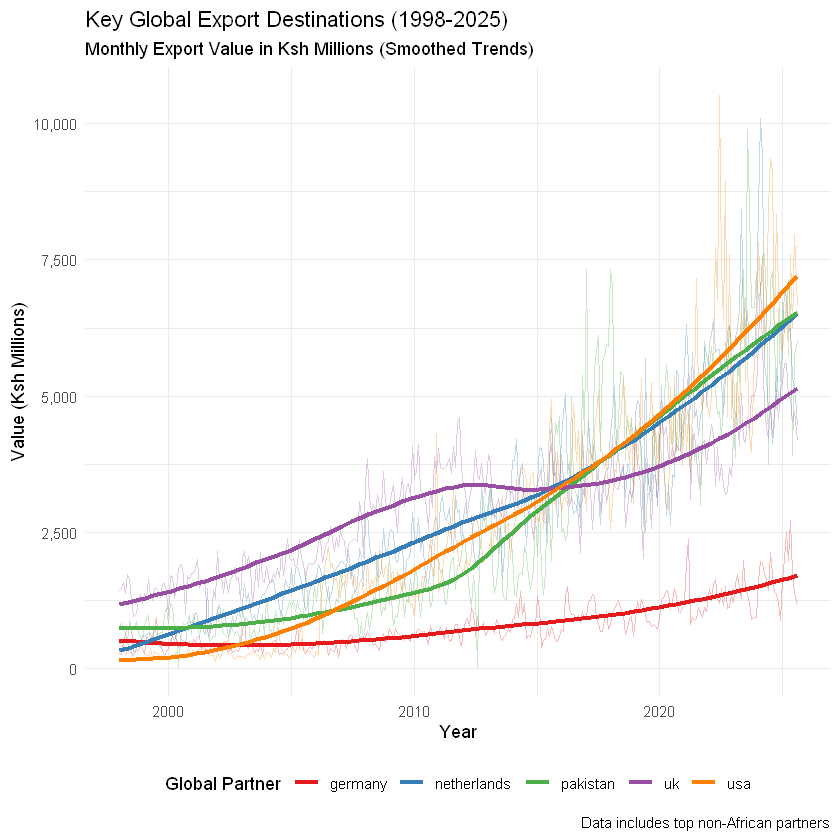

In [14]:
# 1. Reshape for the Top 5 Global partners in the dataset
df_top_global <- df_row %>%
  dplyr::select(date, uk, usa, pakistan, netherlands, germany) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Partner", values_to = "Value")

# 2. Plotting the Global Trends
ggplot(df_top_global, aes(x = date, y = Value, color = Partner)) +
  geom_line(linewidth = 0.5, alpha = 0.3) + # Lighter raw lines
  geom_smooth(method = "loess", formula = y ~ x, se = FALSE, linewidth = 1.2) + # Professional trend lines
  scale_y_continuous(labels = scales::label_comma()) +
  scale_color_brewer(palette = "Set1") +
  labs(
    title = "Key Global Export Destinations (1998-2025)",
    subtitle = "Monthly Export Value in Ksh Millions (Smoothed Trends)",
    x = "Year", y = "Value (Ksh Millions)",
    color = "Global Partner",
    caption = "Data includes top non-African partners"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

## 3. Analysis: The Strategic Pivot (Western vs. Asian Markets)

This is a high-level strategic visualization. We are going to group the Traditional West (UK, USA, Netherlands, Germany) and compare them against the Emerging East (Pakistan, China, India, UAE).

**Goal:** To see if the East has finally overtaken the West in terms of total export value.

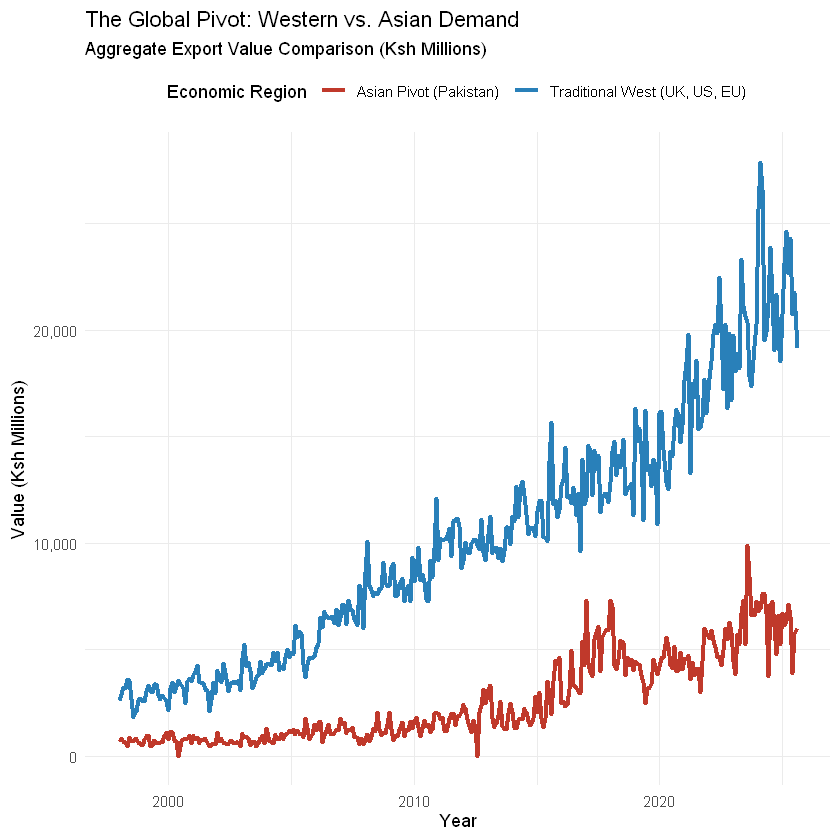

In [15]:
# 1. Aggregate into Blocs
df_blocs <- df_row %>%
  dplyr::mutate(
    # Aggregating Traditional Western Partners (US + European countries in dataset)
    West = usa + uk + netherlands + germany + france + belgium,
    # Pakistan as a proxy for the Asian/Emerging Market pivot
    Asia_Pakistan = pakistan
  ) %>%
  dplyr::select(date, West, Asia_Pakistan) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Bloc", values_to = "Value")

# 2. Plotting the Pivot Comparison
ggplot(df_blocs, aes(x = date, y = Value, color = Bloc)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(
    values = c("West" = "#2980b9", "Asia_Pakistan" = "#c0392b"),
    labels = c("Asian Pivot (Pakistan)", "Traditional West (UK, US, EU)")
  ) +
  scale_y_continuous(labels = scales::label_comma()) +
  labs(
    title = "The Global Pivot: Western vs. Asian Demand",
    subtitle = "Aggregate Export Value Comparison (Ksh Millions)",
    x = "Year", y = "Value (Ksh Millions)",
    color = "Economic Region"
  ) +
  theme_minimal() +
  theme(legend.position = "top")

## Insights
**The Pakistan 'Tea Pulse':** Note how the red line for Pakistan has its own distinct rhythm compared to the Western bloc—this is largely the global tea market at work.

**The Netherlands' Stability:** You'll likely see the Netherlands (flowers/horticulture) being one of the most stable and growing European markets compared to the UK.

## 4. Market Share Analysis.
 We are going to look at where Kenya's money is coming from by grouping the world into five major categories: Africa, Europe, USA, Asia (Pakistan), and the Rest of the World.

By looking at the "Portfolio Mix," you can see if Kenya is becoming more or less dependent on its neighbors versus international giants.

**The Strategy:** Combining African and Global Data
Since the African exports are so significant, we will merge the total from your value_exports_african.csv with the individual country data from value_exports_restofworld.csv.


Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




[1] "Regional Data Summary (Recent 6 months):"


date,Africa,Europe,USA,Asia_Pakistan,Others
<date>,<int>,<int>,<int>,<int>,<int>
1998-07-01,5252,2400,279,745,1616
1998-08-01,5151,1696,144,715,1443
1998-10-01,4878,2462,158,642,1744
1998-11-01,4404,2518,202,586,1379
1998-12-01,5154,2424,189,497,1333
1998-09-01,5163,1933,194,859,1712


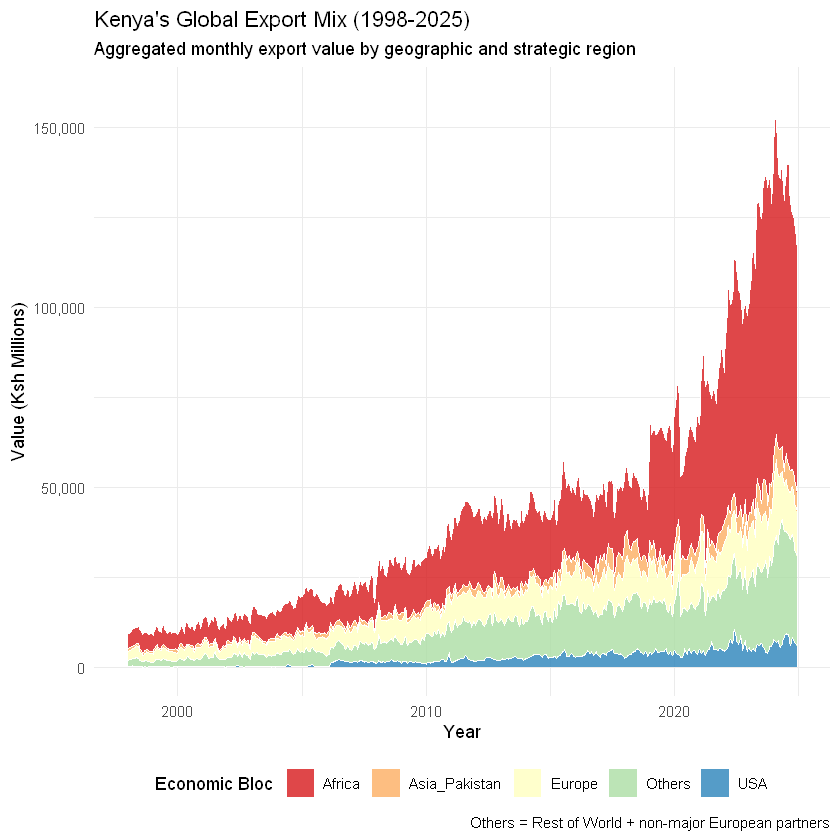

In [16]:
library(tidyverse)
library(scales)
library(lubridate)

# 1. Setup Paths (From notebooks/r to data/cleaned)
data_dir <- "../../data/cleaned/"
file_african <- paste0(data_dir, "value_exports_african.csv")
file_row <- paste0(data_dir, "value_exports_restofworld.csv")

# 2. Load and Clean African Exports (The Africa Total)
df_africa_total <- read.csv(file_african, stringsAsFactors = FALSE) %>%
  dplyr::mutate(date = as.Date(paste(year, month, "01", sep = "-"), format = "%Y-%B-%d")) %>%
  dplyr::select(date, africa_total = total)

# 3. Load and Clean Global Top Partners
df_row <- read.csv(file_row, stringsAsFactors = FALSE) %>%
  dplyr::mutate(date = as.Date(paste(year, month, "01", sep = "-"), format = "%Y-%B-%d")) %>%
  dplyr::select(date, uk, germany, usa, netherlands, pakistan, france, belgium, global_total = total)

# 4. Merge and Group into Regions
df_regions <- dplyr::inner_join(df_row, df_africa_total, by = "date") %>%
  dplyr::mutate(
    # Regional Grouping
    Europe = uk + germany + netherlands + france + belgium,
    USA = usa,
    Asia_Pakistan = pakistan,
    Africa = africa_total,
    # Calculate everything else as 'Others'
    Others = global_total - (Europe + USA + Asia_Pakistan + Africa)
  ) %>%
  dplyr::select(date, Africa, Europe, USA, Asia_Pakistan, Others) %>%
  # Reshape for plotting
  tidyr::pivot_longer(cols = -date, names_to = "Region", values_to = "Value")

# 5. Visualization: The Global Portfolio Mix
# Using a stacked area chart to show how the "share" changes over time
ggplot(df_regions, aes(x = date, y = Value, fill = Region)) +
  geom_area(alpha = 0.8, color = "white", linewidth = 0.1) +
  scale_y_continuous(labels = scales::label_comma()) +
  scale_fill_brewer(palette = "Spectral") +
  labs(
    title = "Kenya's Global Export Mix (1998-2025)",
    subtitle = "Aggregated monthly export value by geographic and strategic region",
    x = "Year", y = "Value (Ksh Millions)",
    fill = "Economic Bloc",
    caption = "Others = Rest of World + non-major European partners"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

# Final Inspection
print("Regional Data Summary (Recent 6 months):")
tail(df_regions %>% tidyr::pivot_wider(names_from = Region, values_from = Value))